# Implementing ridge regression via gradient descent

In this assignment, we will implement ridge regression via gradient descent. We will:
- Convert a dataframe into a Numpy array (if applicable)
- Write a Numpy function to compute the derivative of the regression weights with respect to a single feature
- Write gradient descent function to compute the regression weights given an initial weight vector, step size, tolerance, and L2 penalty

We will continue to use the House data from previous assignments.

## Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## Loading Data

In [2]:
sales = pd.read_csv("../../data/kc_house_data.csv").sort_values(['sqft_living','price'])
train_data = pd.read_csv("../../data/kc_house_train_data.csv").sort_values(['sqft_living','price'])
test_data = pd.read_csv("../../data/kc_house_test_data.csv").sort_values(['sqft_living','price'])

## Helping Function

get_numpy_data, a function from Module 2 that takes a dataframe, a list of features (e.g. [‘sqft_living’, ‘bedrooms’]), to be used as inputs, and a name of the output (e.g. ‘price’). This function returns a ‘feature_matrix’ (2D array) consisting of first a column of ones followed by columns containing the values of the input features in the data set in the same order as the input list. It alsos return an ‘output_array’ which is an array of the values of the output in the data set (e.g. ‘price’).

In [3]:
def get_numpy_data(dataframe, features, output):
    # feature_vals is the actual numeric data
    features_vals = dataframe[features].to_numpy()
    features_matrix = np.column_stack( [np.ones(len(dataframe)), features_vals] )
    output_array = dataframe[output].to_numpy()
    return features_matrix, output_array

predict_output, a function from Module 2. This function accepts a 2D array ‘feature_matrix’ and a 1D array ‘weights’ and return a 1D array ‘predictions’.

In [4]:
def predict_output(feature_matrix, weights):
    return feature_matrix @ weights

## Gradient Descent

The amount by which we move in the negative gradient direction is called the ‘step size’. We stop when we are ‘sufficiently close’ to the optimum. Unlike in Module 2, this time we will set a maximum number of iterations and take gradient steps until we reach this maximum number. If no maximum number is supplied, the maximum should be set 100 by default. 

Write a gradient descent function using your derivative function above. For each step in the gradient descent, we update the weight for each feature before computing our stopping criteria.  The function will take the following parameters:
- 2D feature matrix
- array of output values
- initial weights
- step size
- L2 penalty
- maximum number of iterations

In [5]:
def ridge_gradient_descent(feature_matrix, output, initial_weights, step_size, l2_penalty, max_iterations=100):
    weights = np.array(initial_weights, dtype=float)

    for _ in range(max_iterations):
        predictions = feature_matrix @ weights
        errors = predictions - output
        gradient = 2 * (feature_matrix.T @ errors)
        penalty = 2 * l2_penalty * weights
        penalty[0] = 0.0
        gradient += penalty
        weights -= step_size * gradient

    return weights

## Model With a Single Feature

The L2 penalty gets its name because it causes weights to have small L2 norms than otherwise. Let's see how large weights get penalized. Let us consider a simple model with 1 feature.
- features: ‘sqft_living’
- output: ‘price’

In [6]:
simple_features = ['sqft_living']
my_output = 'price'
(simple_feature_matrix, output) = get_numpy_data(train_data, simple_features, my_output)
(simple_test_feature_matrix, test_output) = get_numpy_data(test_data, simple_features, my_output)

First, let’s consider no regularization:

In [7]:
l2_penalty = 0.
step_size = 1e-12
max_iterations = 1000
initial_weights = [0.,0.]
simple_weights_0_penalty = ridge_gradient_descent(simple_feature_matrix, output, initial_weights, step_size, l2_penalty, max_iterations)

In [8]:
simple_weights_0_penalty

array([-1.63113515e-01,  2.63024369e+02])

Next, let’s consider high regularization:

In [9]:
l2_penalty = 1e11
step_size = 1e-12
max_iterations = 1000
initial_weights = [0.,0.]
simple_weights_high_penalty = ridge_gradient_descent(simple_feature_matrix, output, initial_weights, step_size, l2_penalty, max_iterations)

In [10]:
simple_weights_high_penalty

array([  9.76730382, 124.57217567])

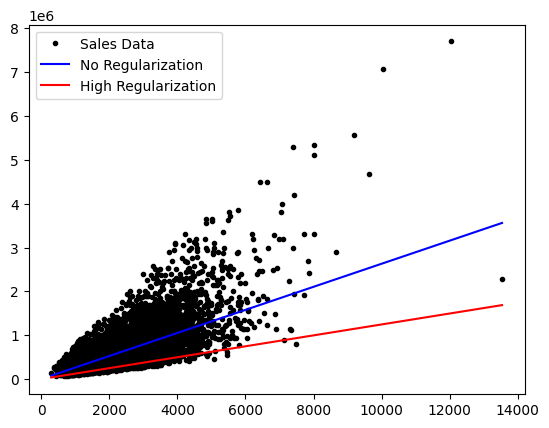

In [11]:
plt.plot(
    simple_feature_matrix[:,1],
    output,
    'k.',
    label='Sales Data'
)
plt.plot(
    simple_feature_matrix[:,1],
    predict_output(simple_feature_matrix, simple_weights_0_penalty),
    'b-',
    label='No Regularization'
)
plt.plot(
    simple_feature_matrix[:,1],
    predict_output(simple_feature_matrix, simple_weights_high_penalty),
    'r-',
    label='High Regularization'
)
plt.legend()
plt.show()

Compute the RSS on the TEST data for the following three sets of weights:

- The initial weights (all zeros)

In [12]:
initial_predictions = predict_output(simple_test_feature_matrix, [0.,0.])
initial_rss = ((test_output - initial_predictions) ** 2).sum()
print ( f'{initial_rss:e}' )

1.784273e+15


- The weights learned with no regularization

In [13]:
predictions_0_penalty = predict_output(simple_test_feature_matrix, simple_weights_0_penalty)
rss_0_penalty = ((test_output - predictions_0_penalty) ** 2).sum()
print ( f'{rss_0_penalty:e}' )

2.757236e+14


- The weights learned with high regularization

In [14]:
predictions_high_penalty = predict_output(simple_test_feature_matrix, simple_weights_high_penalty)
rss_high_penalty = ((test_output - predictions_high_penalty) ** 2).sum()
print ( f'{rss_high_penalty:e}' )

6.946421e+14


## Model With Two Features

In [15]:
model_features = ['sqft_living', 'sqft_living15']
my_output = 'price'
(feature_matrix, output) = get_numpy_data(train_data, model_features, my_output)
(test_feature_matrix, test_output) = get_numpy_data(test_data, model_features, my_output)

First, let’s consider no regularization

In [16]:
l2_penalty = 0.
step_size = 1e-12
max_iterations = 1000
initial_weights = [0.,0.,0.]
multiple_weights_0_penalty = ridge_gradient_descent(feature_matrix, output, initial_weights, step_size, l2_penalty, max_iterations)

In [17]:
multiple_weights_0_penalty

array([ -0.35743483, 243.05416982,  22.41481497])

Next, let’s consider high regularization

In [18]:
l2_penalty = 1e11
step_size = 1e-12
max_iterations = 1000
initial_weights = [0.,0.,0.]
multiple_weights_high_penalty = ridge_gradient_descent(feature_matrix, output, initial_weights, step_size, l2_penalty, max_iterations)

In [19]:
multiple_weights_high_penalty

array([ 6.74296579, 91.48927365, 78.43658766])

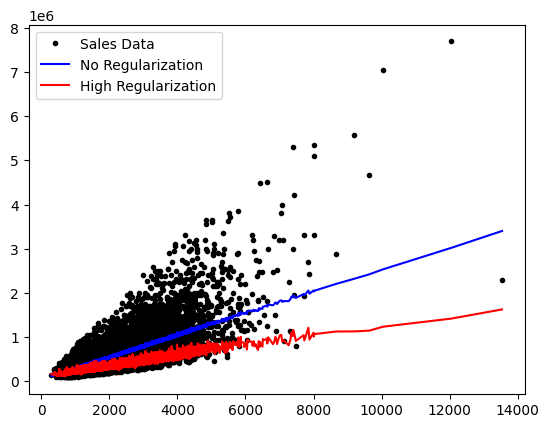

In [20]:
mask = feature_matrix[:, 1] < 140000

plt.plot(
    feature_matrix[mask,1],
    output[mask],
    'k.',
    label='Sales Data'
)
plt.plot(
    feature_matrix[mask,1],
    predict_output(feature_matrix[mask], multiple_weights_0_penalty),
    'b-',
    label='No Regularization'
)
plt.plot(
    feature_matrix[mask,1],
    predict_output(feature_matrix[mask], multiple_weights_high_penalty),
    'r-',
    label='High Regularization'
)
plt.legend()
plt.show()

Compute the RSS on the TEST data for the following three sets of weights:

- The initial weights (all zeros)

In [21]:
initial_predictions = predict_output(test_feature_matrix, [0.,0.,0.])
initial_rss = ((test_output - initial_predictions) ** 2).sum()
print ( f'{initial_rss:e}' )

1.784273e+15


- The weights learned with no regularization

In [22]:
predictions_0_penalty = predict_output(test_feature_matrix, multiple_weights_0_penalty)
rss_0_penalty = ((test_output - predictions_0_penalty) ** 2).sum()
print ( f'{rss_0_penalty:e}' )

2.740676e+14


- The weights learned with high regularization

In [23]:
predictions_high_penalty = predict_output(test_feature_matrix, multiple_weights_high_penalty)
rss_high_penalty = ((test_output - predictions_high_penalty) ** 2).sum()
print ( f'{rss_high_penalty:e}' )

5.004048e+14


Predict the house price for the 1st house in the test set using the no regularization and high regularization models. 

In [24]:
# actual price
test_output[0]

np.float64(276000.0)

In [25]:
# predicted price with no regularization
predict_output(test_feature_matrix[0],multiple_weights_0_penalty)

np.float64(119965.53746060442)

In [26]:
# predicted price with high regularization
predict_output(test_feature_matrix[0],multiple_weights_high_penalty)

np.float64(138962.801684115)

**The weights learned with high regularization make better predictions for the first house in the test set**